In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [59]:
df = pd.read_csv("Data/big_mart_sales.csv")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [60]:
df.shape

(8523, 12)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [62]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [63]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [64]:
features = [
    "Item_Weight",
    "Item_Visibility",
    "Item_MRP",
    "Outlet_Establishment_Year"
]

In [65]:
X = df[features].copy()

In [66]:
X = X.fillna(X.median())

In [67]:
sales_median = df["Item_Outlet_Sales"].median()

df["Sales_Class"] = (
    df["Item_Outlet_Sales"] >= sales_median
).astype(int)

print("Sales Median:", sales_median)

print(df["Sales_Class"].value_counts())

Sales Median: 1794.331
Sales_Class
1    4266
0    4257
Name: count, dtype: int64


In [68]:
X_class = df[features].copy()

X_class = X_class.fillna(X_class.median())

y_class = df["Sales_Class"]

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (6818, 4)
Testing : (1705, 4)


In [70]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [71]:
k_values = range(1, 21)

accuracy_scores = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)

    accuracy_scores.append(accuracy)

print(accuracy_scores)

[0.6686217008797654, 0.6463343108504399, 0.7032258064516129, 0.6967741935483871, 0.7214076246334311, 0.7214076246334311, 0.7231671554252199, 0.7278592375366569, 0.7296187683284457, 0.7325513196480938, 0.7419354838709677, 0.7425219941348974, 0.7454545454545455, 0.7407624633431085, 0.7454545454545455, 0.7425219941348974, 0.7472140762463343, 0.7436950146627566, 0.7425219941348974, 0.7501466275659824]


In [72]:
knn_classification_results = pd.DataFrame({
    "K": list(k_values),
    "Accuracy": accuracy_scores
})

knn_classification_results

,K,Accuracy
0,1,0.668622
1,2,0.646334
2,3,0.703226
3,4,0.696774
4,5,0.721408
5,6,0.721408
6,7,0.723167
7,8,0.727859
8,9,0.729619
9,10,0.732551


In [73]:
best_k = k_values[np.argmax(accuracy_scores)]

best_accuracy = max(accuracy_scores)

print("Best K:", best_k)
print(f"Best Accuracy: {best_accuracy * 100:.2f}%")

Best K: 20
Best Accuracy: 75.01%


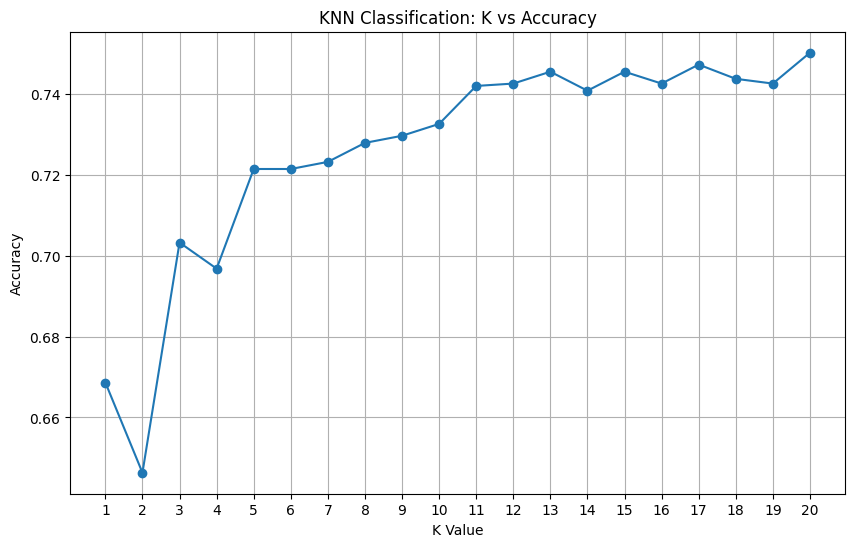

In [74]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    accuracy_scores,
    marker="o"
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Classification: K vs Accuracy")

plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [75]:
knn_classifier = KNeighborsClassifier(
    n_neighbors=best_k
)

knn_classifier.fit(
    X_train_scaled,
    y_train
)

KNeighborsClassifier(n_neighbors=20)

In [76]:
y_pred_class = knn_classifier.predict(X_test_scaled)

print(y_pred_class[:20])

[0 0 1 1 0 1 1 0 1 1 0 1 1 0 0 1 0 0 0 0]


In [77]:
accuracy = accuracy_score(
    y_test,
    y_pred_class
)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 75.01%


In [78]:
precision = precision_score(
    y_test,
    y_pred_class
)

recall = recall_score(
    y_test,
    y_pred_class
)

f1 = f1_score(
    y_test,
    y_pred_class
)

print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Precision: 0.7380
Recall   : 0.7761
F1-Score : 0.7566


In [79]:
print(
    classification_report(
        y_test,
        y_pred_class,
        target_names=[
            "Low Sales",
            "High Sales"
        ]
    )
)

              precision    recall  f1-score   support

   Low Sales       0.76      0.72      0.74       852
  High Sales       0.74      0.78      0.76       853

    accuracy                           0.75      1705
   macro avg       0.75      0.75      0.75      1705
weighted avg       0.75      0.75      0.75      1705



In [80]:
cm = confusion_matrix(
    y_test,
    y_pred_class
)

print(cm)

[[617 235]
 [191 662]]


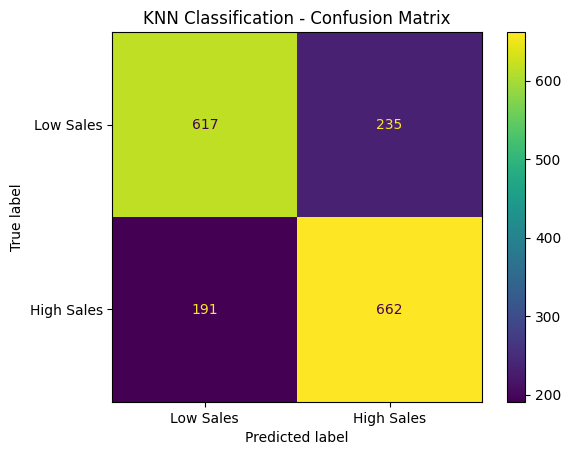

In [81]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Low Sales",
        "High Sales"
    ]
)

disp.plot()

plt.title("KNN Classification - Confusion Matrix")

plt.show()

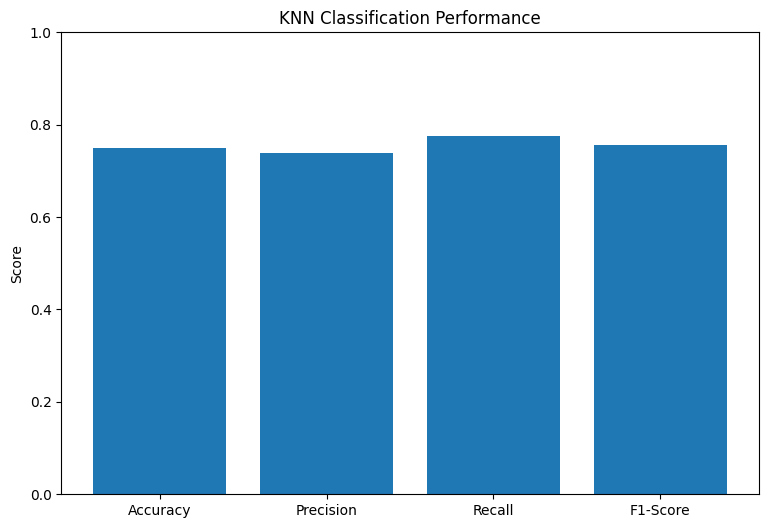

In [82]:
metrics_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

metrics_values = [
    accuracy,
    precision,
    recall,
    f1
]

plt.figure(figsize=(9, 6))

plt.bar(
    metrics_names,
    metrics_values
)

plt.ylim(0, 1)

plt.ylabel("Score")
plt.title("KNN Classification Performance")

plt.show()

In [83]:
print("=" * 50)
print("KNN CLASSIFICATION RESULTS")
print("=" * 50)

print(f"Best K   : {best_k}")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

KNN CLASSIFICATION RESULTS
Best K   : 20
Accuracy : 0.7501
Precision: 0.7380
Recall   : 0.7761
F1-Score : 0.7566


In [84]:
KNeighborsRegressor

sklearn.neighbors._regression.KNeighborsRegressor

In [85]:
X_reg = df[features].copy()

X_reg = X_reg.fillna(X_reg.median())

y_reg = df["Item_Outlet_Sales"]

In [86]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Training:", X_train_reg.shape)
print("Testing :", X_test_reg.shape)

Training: (6818, 4)
Testing : (1705, 4)


In [87]:
scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(
    X_train_reg
)

X_test_reg_scaled = scaler_reg.transform(
    X_test_reg
)

In [88]:
k_values = range(1, 21)

rmse_scores = []
mae_scores = []
r2_scores = []

for k in k_values:

    knn_reg = KNeighborsRegressor(
        n_neighbors=k
    )

    knn_reg.fit(
        X_train_reg_scaled,
        y_train_reg
    )

    y_pred_reg = knn_reg.predict(
        X_test_reg_scaled
    )

    mae = mean_absolute_error(
        y_test_reg,
        y_pred_reg
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_reg,
            y_pred_reg
        )
    )

    r2 = r2_score(
        y_test_reg,
        y_pred_reg
    )

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

In [89]:
knn_regression_results = pd.DataFrame({
    "K": list(k_values),
    "MAE": mae_scores,
    "RMSE": rmse_scores,
    "R2": r2_scores
})

knn_regression_results

,K,MAE,RMSE,R2
0,1,1309.764884,1844.050235,-0.251125
1,2,1136.907779,1609.899092,0.046430
2,3,1080.707556,1513.680506,0.157007
3,4,1045.247913,1463.351255,0.212134
4,5,1025.834103,1426.831948,0.250967
5,6,1022.864570,1413.045775,0.265371
6,7,1010.060718,1397.813118,0.281125
7,8,999.703240,1380.829048,0.298488
8,9,992.977374,1367.565856,0.311900
9,10,991.885722,1365.114111,0.314365


In [90]:
best_k_reg = k_values[
    np.argmin(rmse_scores)
]

best_rmse = min(rmse_scores)

print("Best K:", best_k_reg)
print(f"Best RMSE: {best_rmse:.2f}")

Best K: 20
Best RMSE: 1331.25


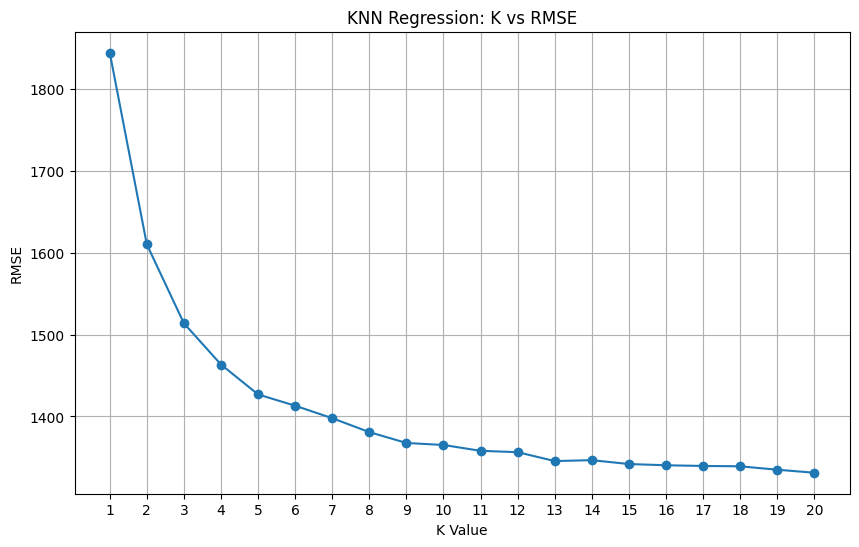

In [91]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    rmse_scores,
    marker="o"
)

plt.xlabel("K Value")
plt.ylabel("RMSE")
plt.title("KNN Regression: K vs RMSE")

plt.xticks(list(k_values))
plt.grid(True)

plt.show()

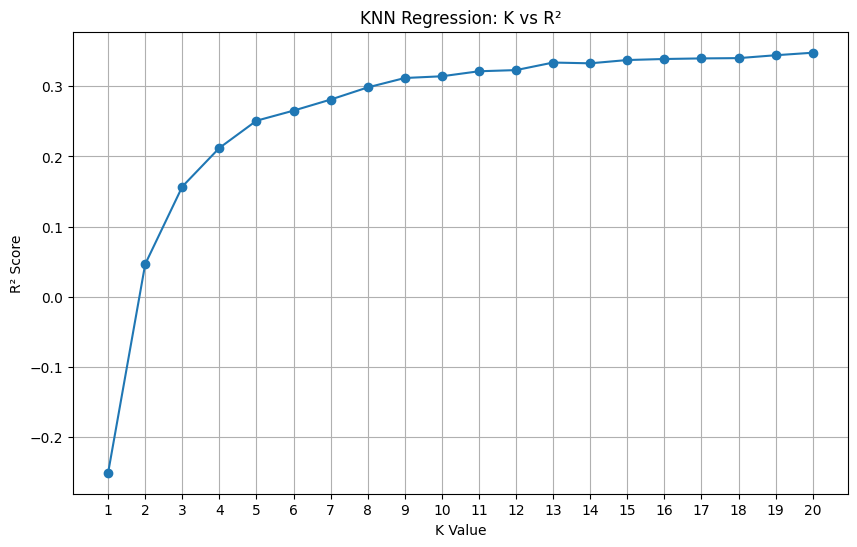

In [92]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    r2_scores,
    marker="o"
)

plt.xlabel("K Value")
plt.ylabel("R² Score")
plt.title("KNN Regression: K vs R²")

plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [93]:
knn_regressor = KNeighborsRegressor(
    n_neighbors=best_k_reg
)

knn_regressor.fit(
    X_train_reg_scaled,
    y_train_reg
)

KNeighborsRegressor(n_neighbors=20)

In [94]:
y_pred_reg = knn_regressor.predict(
    X_test_reg_scaled
)

print(y_pred_reg[:10])

[1554.60971  665.10091  626.21819 4130.52333 3281.12898  715.76829
 2446.11591 2214.7837  1290.25382 3136.11774]


In [95]:
mae = mean_absolute_error(
    y_test_reg,
    y_pred_reg
)

print(f"MAE: {mae:.2f}")

MAE: 967.58


In [96]:
mse = mean_squared_error(
    y_test_reg,
    y_pred_reg
)

print(f"MSE: {mse:.2f}")

MSE: 1772225.30


In [97]:
rmse = np.sqrt(mse)

print(f"RMSE: {rmse:.2f}")

RMSE: 1331.25


In [98]:
r2 = r2_score(
    y_test_reg,
    y_pred_reg
)

print(f"R² Score: {r2:.4f}")

R² Score: 0.3480


In [99]:
print("=" * 50)
print("KNN REGRESSION RESULTS")
print("=" * 50)

print(f"Best K : {best_k_reg}")
print(f"MAE    : {mae:.2f}")
print(f"MSE    : {mse:.2f}")
print(f"RMSE   : {rmse:.2f}")
print(f"R²     : {r2:.4f}")

KNN REGRESSION RESULTS
Best K : 20
MAE    : 967.58
MSE    : 1772225.30
RMSE   : 1331.25
R²     : 0.3480


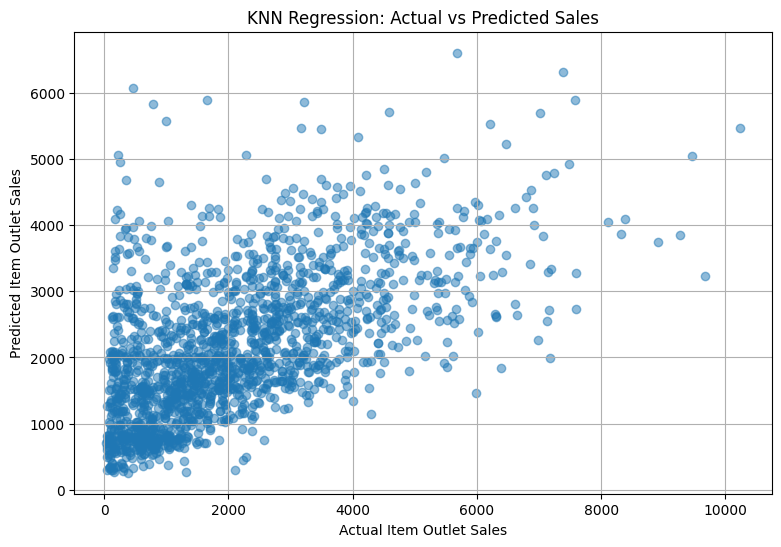

In [100]:
plt.figure(figsize=(9, 6))

plt.scatter(
    y_test_reg,
    y_pred_reg,
    alpha=0.5
)

plt.xlabel("Actual Item Outlet Sales")
plt.ylabel("Predicted Item Outlet Sales")

plt.title(
    "KNN Regression: Actual vs Predicted Sales"
)

plt.grid(True)

plt.show()

In [102]:
comparison = pd.DataFrame({
    "Actual": y_test_reg.values,
    "Predicted": y_pred_reg
})

comparison = comparison.reset_index(drop=True)

comparison.head(20)

,Actual,Predicted
0,1743.0644,1554.60971
1,356.8688,665.10091
2,377.5086,626.21819
3,5778.4782,4130.52333
4,2356.9320,3281.12898
5,865.5400,715.76829
6,4613.9940,2446.11591
7,2410.8618,2214.78370
8,1948.1308,1290.25382
9,1937.4780,3136.11774


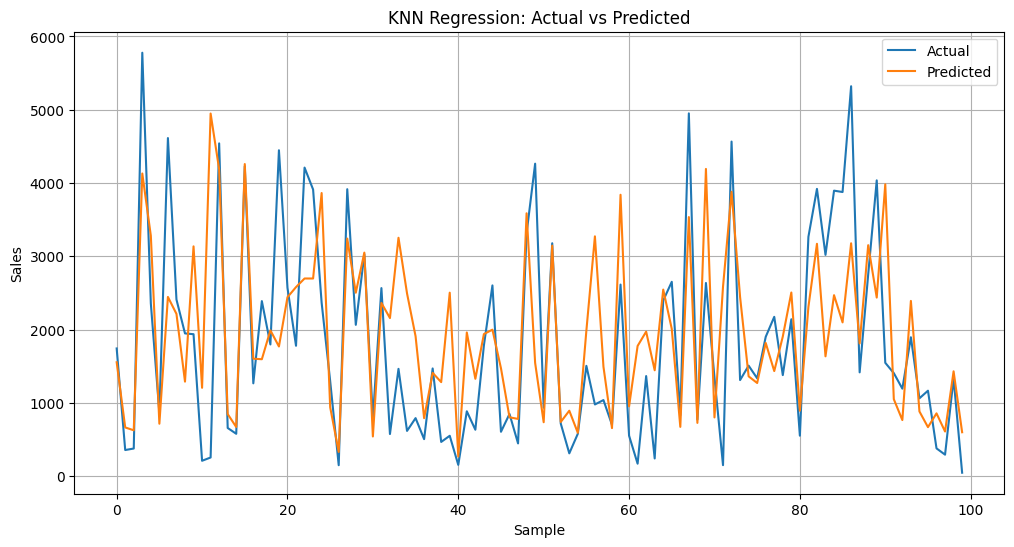

In [103]:
plt.figure(figsize=(12, 6))

plt.plot(
    comparison["Actual"][:100],
    label="Actual"
)

plt.plot(
    comparison["Predicted"][:100],
    label="Predicted"
)

plt.xlabel("Sample")
plt.ylabel("Sales")

plt.title(
    "KNN Regression: Actual vs Predicted"
)

plt.legend()
plt.grid(True)

plt.show()

In [104]:
print("=" * 70)
print("FINAL KNN MODEL RESULTS")
print("=" * 70)

print("\nCLASSIFICATION")
print("-" * 40)
print(f"Best K    : {best_k}")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\nREGRESSION")
print("-" * 40)
print(f"Best K : {best_k_reg}")
print(f"MAE    : {mae:.2f}")
print(f"MSE    : {mse:.2f}")
print(f"RMSE   : {rmse:.2f}")
print(f"R²     : {r2:.4f}")

FINAL KNN MODEL RESULTS

CLASSIFICATION
----------------------------------------
Best K    : 20
Accuracy  : 0.7501
Precision : 0.7380
Recall    : 0.7761
F1-Score  : 0.7566

REGRESSION
----------------------------------------
Best K : 20
MAE    : 967.58
MSE    : 1772225.30
RMSE   : 1331.25
R²     : 0.3480
